In [57]:
import pandas as pd   #data handeling library

In [58]:
# read csv file into pandas dataframe
data = pd.read_csv("House Price India.csv")

In [59]:
data.head(3)
# data.tail(3)

,id,Date,number of bedrooms,number of bathrooms,living area,lot area,number of floors,waterfront present,number of views,condition of the house,...,Built Year,Renovation Year,Postal Code,Lattitude,Longitude,living_area_renov,lot_area_renov,Number of schools nearby,Distance from the airport,Price
0,6762810635,42491,4,2.50,2920,4000,1.5,0,0,5,...,1909,0,122004,52.8878,-114.470,2470,4000,2,51,1400000
1,6762810998,42491,5,2.75,2910,9480,1.5,0,0,3,...,1939,0,122004,52.8852,-114.468,2940,6600,1,53,1200000
2,6762812605,42491,4,2.50,3310,42998,2.0,0,0,3,...,2001,0,122005,52.9532,-114.321,3350,42847,3,76,838000


In [60]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 14619 entries, 0 to 14618
Data columns (total 23 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   id                                     14619 non-null  int64  
 1   Date                                   14619 non-null  int64  
 2   number of bedrooms                     14619 non-null  int64  
 3   number of bathrooms                    14619 non-null  float64
 4   living area                            14619 non-null  int64  
 5   lot area                               14619 non-null  int64  
 6   number of floors                       14619 non-null  float64
 7   waterfront present                     14619 non-null  int64  
 8   number of views                        14619 non-null  int64  
 9   condition of the house                 14619 non-null  int64  
 10  grade of the house                     14619 non-null  int64  
 11  Area of the h

In [61]:
data.columns

Index(['id', 'Date', 'number of bedrooms', 'number of bathrooms',
       'living area', 'lot area', 'number of floors', 'waterfront present',
       'number of views', 'condition of the house', 'grade of the house',
       'Area of the house(excluding basement)', 'Area of the basement',
       'Built Year', 'Renovation Year', 'Postal Code', 'Lattitude',
       'Longitude', 'living_area_renov', 'lot_area_renov',
       'Number of schools nearby', 'Distance from the airport', 'Price'],
      dtype='str')

In [62]:
# data.describe()
# data['Price'].describe()
# data['Price'].describe().reset_index()
# round(data['Price'].describe().reset_index(), 2)
# round(data['Price'].describe().reset_index(), 2)
# round(data['Price'].describe().reset_index()["Price"], 2)

#or

stats = data['Price'].describe().reset_index()
stats['Price'] = round(stats['Price'])

In [63]:
# stats

In [64]:
# data.isna()   #isnull() ? --> is value missing?   true->missing, false->not missing
data.isna().sum() #number of null cell

id                                       0
Date                                     0
number of bedrooms                       0
number of bathrooms                      0
living area                              0
lot area                                 0
number of floors                         0
waterfront present                       0
number of views                          0
condition of the house                   0
grade of the house                       0
Area of the house(excluding basement)    0
Area of the basement                     0
Built Year                               0
Renovation Year                          0
Postal Code                              0
Lattitude                                0
Longitude                                0
living_area_renov                        0
lot_area_renov                           0
Number of schools nearby                 0
Distance from the airport                0
Price                                    0
dtype: int6

In [65]:
# data.isna().sum().sum()

In [66]:
# checking duplicated rows/entry
# data.duplicated()
data.duplicated().sum()

np.int64(0)

In [67]:
# for na/null values
data.dropna(inplace=True)      #permanently removes rows that contain at least one missing value (NaN, None, pd.NA, etc)
# for duplicated vlaues
data.drop_duplicates(inplace=True)       # removes rows that are completely identical to a previous row

In [68]:
# group data by condition of house and get average price form that
# data.groupby("condition of the house")['Price'].mean()
groupByCond = data.groupby("condition of the house")['Price'].mean().sort_values(ascending=False)  #also sort the values in descending
groupByCond


condition of the house
5    609954.024276
3    539336.477968
4    521082.494579
2    312891.400000
1    285497.222222
Name: Price, dtype: float64

In [69]:
# groupByScl = data.groupby("Number of schools nearby")['Price'].mean()
# groupByScl

In [70]:
import matplotlib.pyplot as plt

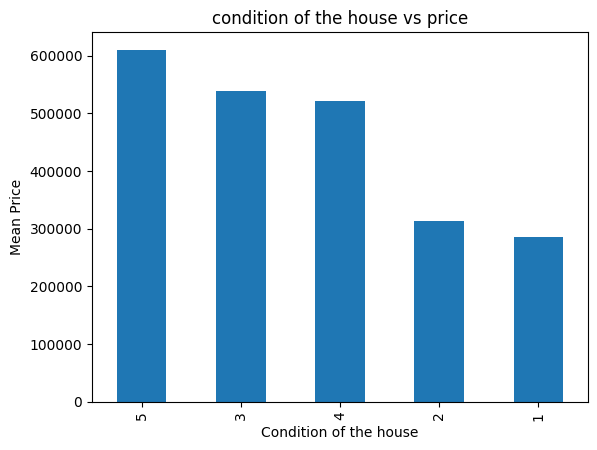

In [71]:
groupByCond.plot(kind="bar")
plt.title("condition of the house vs price")
plt.ylabel("Mean Price")
plt.xlabel("Condition of the house")
plt.show()

In [72]:
data.columns

Index(['id', 'Date', 'number of bedrooms', 'number of bathrooms',
       'living area', 'lot area', 'number of floors', 'waterfront present',
       'number of views', 'condition of the house', 'grade of the house',
       'Area of the house(excluding basement)', 'Area of the basement',
       'Built Year', 'Renovation Year', 'Postal Code', 'Lattitude',
       'Longitude', 'living_area_renov', 'lot_area_renov',
       'Number of schools nearby', 'Distance from the airport', 'Price'],
      dtype='str')

In [93]:
# feature engineering
#fitting tree based model ---> decision tree
# independent variables /inputs
X = data[['number of bedrooms', 'number of bathrooms', 'living area', 'lot area', 'number of floors', 'grade of the house', 'condition of the house', 'Lattitude', 'Longitude', 'Postal Code', 'Distance from the airport', 'Number of schools nearby', 'number of views', 'waterfront present', 'Area of the house(excluding basement)', 'Area of the basement','living_area_renov', 'lot_area_renov']] #assign those specific columns to X
# dependent variable / output  --> this is what model learns to predict for unknown Y
Y = data[["Price"]]


In [94]:
X.shape

(14619, 18)

In [95]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)   #20% dataset for test, 80% for training

In [96]:
X_train.shape  #gives the number of data to be used for training

(11695, 18)

In [97]:
from sklearn.model_selection import GridSearchCV  #automatic model optimizer--> cretes and try lots of combinatons of model and selects the best, analyze performance

# Decision Tree Regressor

In [98]:
from sklearn.tree import DecisionTreeRegressor   #model import

# Model will try combinations of:
param_grid = {
    "criterion" : ["mse", "friedman_mse", "mae"],
    "splitter" : ["best", "random"],
    "max_depth" : [None, 10, 20, 30, 40, 50],
    "min_samples_split" : [2, 5, 10],
    "min_samples_leaf" : [1, 2, 4]
}

In [99]:
#creating model
tree_model = DecisionTreeRegressor(random_state=42)

In [100]:
grid_tree = GridSearchCV(estimator=tree_model, param_grid=param_grid)   # wraps model in GridSearch

In [101]:
#training model
grid_tree.fit(X_train, Y_train)  

C:\Users\arjun\AppData\Roaming\Python\Python314\site-packages\sklearn\model_selection\_validation.py:490: FitFailedWarning: 
1080 fits failed out of a total of 1620.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
540 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\arjun\AppData\Roaming\Python\Python314\site-packages\sklearn\model_selection\_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\arjun\AppData\Roaming\Python\Python314\site-packages\sklearn\base.py", line 1329, in wrapper
    estimator._validate_params()
    ~~~~~~~~~~~~~~~~~~~~~~~~~~^^
  File "C:\Users\arjun\AppData\Roaming\Py

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeR...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'criterion': ['mse', 'friedman_mse', ...], 'max_depth': [None, 10, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time 

In [102]:
#best params
grid_tree.best_params_

{'criterion': 'friedman_mse',
 'max_depth': 10,
 'min_samples_leaf': 4,
 'min_samples_split': 10,
 'splitter': 'best'}

In [104]:
# predicting
grid_preds = grid_tree.predict(X_test)

In [105]:
grid_preds

array([ 584229.35046729,  477985.        ,  344195.65217391, ...,
        733085.78512397,  417676.47058824, 1276811.11111111],
      shape=(2924,))

In [106]:
#Evaluation  -> using all 3 metrices
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(Y_test, grid_preds)
rmse = np.sqrt(mean_squared_error(Y_test, grid_preds))
r2 = r2_score(Y_test, grid_preds)      # values renge from 0 to 1,    1->fully correct -> overfitting

In [107]:
print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 86268.46750179175
RMSE: 157406.61508047677
R2: 0.8325844584598998


# model2 -> linear regression

In [108]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()

In [109]:
lr_model.fit(X_train, Y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [110]:
lr_preds = lr_model.predict(X_test)

In [111]:
lr_preds

array([[ 535491.67853388],
       [ 485443.10767891],
       [ 601252.75752945],
       ...,
       [ 786010.92562728],
       [ 607491.75083956],
       [1707947.43738219]], shape=(2924, 1))

In [112]:
lr_mae = mean_absolute_error(Y_test, lr_preds)
lr_rmse = np.sqrt(mean_squared_error(Y_test, lr_preds))
lr_r2 = r2_score(Y_test, lr_preds)      # values renge from 0 to 1,    1->fully correct -> overfitting

In [113]:
print("MAE:", lr_mae)
print("RMSE:", lr_rmse)
print("R2:", lr_r2)

MAE: 129546.40597069182
RMSE: 214671.47196970074
R2: 0.6886144315693704


# Random Forest Model

In [129]:
from sklearn.ensemble import RandomForestRegressor
rfr_model = RandomForestRegressor()

In [164]:
param_gridrfr = {
    "max_depth" : [5,10,15,20,25],
    "n_estimators" : [2,3,4,5,6,7,8,9,10,11,12,13,14,15],
}

In [166]:
gridrfr = GridSearchCV(rfr_model, param_gridrfr)

In [167]:
gridrfr.fit(X_train, Y_train.values.ravel())

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestRegressor()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [5, 10, ...], 'n_estimators': [2, 3, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the

In [152]:
gridrfr.best_params_

{'max_depth': 15, 'n_estimators': 10}

In [153]:
rfrpredictions = gridrfr.predict(X_test)

In [154]:
rfrpredictions

array([ 542298.04727415,  448780.18888889,  377401.30952381, ...,
        672363.07275945,  431992.88480392, 1436900.        ],
      shape=(2924,))

In [160]:
rfr_mae = mean_absolute_error(Y_test, rfrpredictions)
rfr_rmse = np.sqrt(mean_squared_error(Y_test, rfrpredictions))
rfr_r2 = r2_score(Y_test, rfrpredictions)

In [161]:
print("MAE:", rfr_mae)
print("RMSE:", rfr_rmse)
print("R2:", rfr_r2)

MAE: 73334.50680040978
RMSE: 138131.3421951465
R2: 0.8710758502465115


# Save & Export Model

In [ ]:
import joblib

#save model
joblib.dump(gridrfr, "model.pkl") #created a file named model.pkl

['model.pkl']

In [170]:
X.columns

Index(['number of bedrooms', 'number of bathrooms', 'living area', 'lot area',
       'number of floors', 'grade of the house', 'condition of the house',
       'Lattitude', 'Longitude', 'Postal Code', 'Distance from the airport',
       'Number of schools nearby', 'number of views', 'waterfront present',
       'Area of the house(excluding basement)', 'Area of the basement',
       'living_area_renov', 'lot_area_renov'],
      dtype='str')